In [4]:
%load_ext autoreload
%autoreload 2
import pprint
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import utils
import pylupnt as pnt

pp = pprint.PrettyPrinter()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# MILP

## Single satellite, single orbit, no resources

In [309]:
# Seed
np.random.seed(0)

# Tasks
targets = ["A", "B", "C", "D"]
N_targets = len(targets)
vtws = np.array(
    [
        [0, 2.5],
        [2, 3.5],
        [2.5, 5.5],
        [3.5, 6.5],
    ]
)
durations = np.array([2, 1, 1.5, 1.5])
rewards = np.arange(1, N_targets + 1)
max_tasks = np.ones(N_targets, dtype=int) * 2

# Tasks
dt = 0.5
task_otws = []
task_idxs = []
for idx in range(N_targets):
    ts = vtws[idx][0]
    te = vtws[idx][1]
    while ts + durations[idx] <= te:
        task_otws.append([ts, ts + durations[idx]])
        task_idxs.append(idx)
        ts += dt
task_otws = np.array(task_otws)
task_idxs = np.array(task_idxs)
N_tasks = len(task_idxs)

# Transition time (random symmetric matrix with zeros on the diagonal)
rnd_matrix = 2 * np.random.rand(N_targets, N_targets)
rnd_matrix[np.diag_indices(N_targets)] = 0
trans_time = (rnd_matrix + rnd_matrix.T) / 2

print("Targets\n", targets)
print("Rewards\n", rewards)
print("VTWs\n", vtws)
print("Durations\n", durations)
print("Margin\n", vtws[:, 1] - vtws[:, 0] - durations)
print("Task idxs\n", task_idxs)
print("Task otws\n", task_otws)
print("Transition times\n", trans_time)

Targets
 ['A', 'B', 'C', 'D']
Rewards
 [1 2 3 4]
VTWs
 [[0.  2.5]
 [2.  3.5]
 [2.5 5.5]
 [3.5 6.5]]
Durations
 [2.  1.  1.5 1.5]
Margin
 [0.5 0.5 1.5 1.5]
Task idxs
 [0 0 1 1 2 2 2 2 3 3 3 3]
Task otws
 [[0.  2. ]
 [0.5 2.5]
 [2.  3. ]
 [2.5 3.5]
 [2.5 4. ]
 [3.  4.5]
 [3.5 5. ]
 [4.  5.5]
 [3.5 5. ]
 [4.  5.5]
 [4.5 6. ]
 [5.  6.5]]
Transition times
 [[0.         1.13884417 1.56642614 1.11292774]
 [1.13884417 0.         0.82102873 1.81736964]
 [1.56642614 0.82102873 0.         0.59993098]
 [1.11292774 1.81736964 0.59993098 0.        ]]


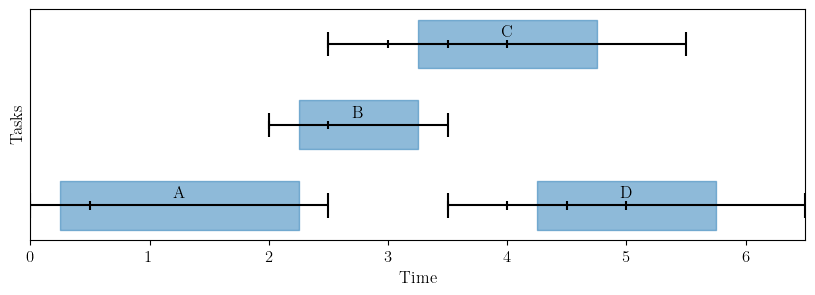

In [310]:
plt.rcParams.update({"font.size": 12})
plt.figure(figsize=(10, 3))
utils.plot_windows(targets, vtws, durations, task_otws, task_idxs)

In [311]:
# Variables
# - (s, p1, p2, ..., pN, e)
x = cp.Variable((N_tasks + 2, N_tasks + 2), boolean=True)
# Objective
# - Maximize the sum of rewards
rho = np.concatenate([[0], rewards[task_idxs], [0]])
objective = cp.Maximize(rho @ cp.sum(x, axis=1))
# Constraints
constraints = []
# - Each task is executed at most N_i times
for i in range(N_targets):
    tmp = np.where(task_idxs == i)[0]
    constraints.append(cp.sum(x[1 + tmp, :]) <= max_tasks[i])

# - Diagonal and dummy start and end tasks
constraints.append(cp.sum(x[0, :]) == 1)
constraints.append(cp.sum(x[:, 0]) == 0)
constraints.append(cp.sum(x[-1, :]) == 0)
constraints.append(cp.sum(x[:, -1]) == 1)
constraints.append(x[np.diag_indices(N_tasks + 2)] == 0)
# - Precedence constraints (what tasks can be executed after each task)
for i in range(N_tasks):
    idx = task_idxs[i]
    feasible_x = np.zeros(N_tasks + 2, dtype=bool)
    feasible_x[-1] = True  # End task
    feasible_x[1:-1] = (
        task_otws[i][1] + 0 * trans_time[idx, task_idxs] <= task_otws[:, 0]
    ) # Next tasks
    constraints.append(x[1 + i, :] <= feasible_x) 
    constraints.append(cp.sum(x[1 + i, :]) == cp.sum(x[:, 1 + i]))

problem = cp.Problem(objective, constraints)
problem.solve()
print("Problem status:", problem.status)
print("Optimal value:", problem.value)

Problem status: optimal
Optimal value: 11.0


In [312]:
# selected_tasks = np.where(x.value[:, 1:-1])[1]
selected_tasks = x.value[:, 1:-1].any(axis=0)
selected_targets = task_idxs[selected_tasks]
print("Selected tasks:", np.where(selected_tasks)[0])
print("Selected targets:", selected_targets)

Selected tasks: [ 0  3  8 11]
Selected targets: [0 1 3 3]


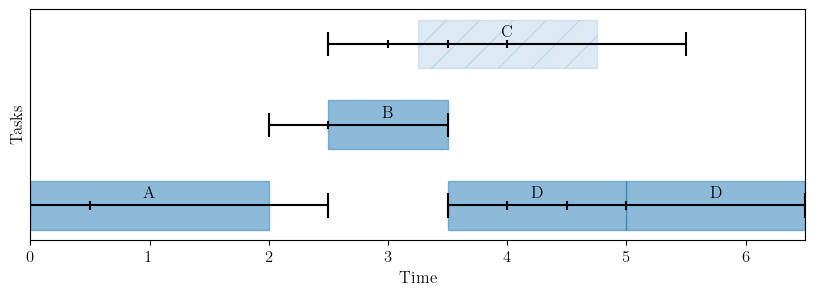

In [313]:
plt.rcParams.update({"font.size": 12})
plt.figure(figsize=(10, 3))
utils.plot_windows(targets, vtws, durations, task_otws, task_idxs, selected_tasks=selected_tasks)

In [262]:
# Constraint verification
seq = np.array([0,1,3,6], dtype=int)

x = np.zeros((N_tasks + 2, N_tasks + 2))
x[0, seq[0] + 1] = 1
x[seq[-1] + 1, -1] = 1
for i in range(len(seq) - 1):
    x[seq[i] + 1, seq[i + 1] + 1] = 1

# Constraints
constraints = []
# - Each task is executed at most N_i times
constraints.append(np.sum(x, axis=0) <= 1)
constraints.append(np.sum(x, axis=1) <= 1)
# - Diagonal and dummy start and end tasks
constraints.append(np.sum(x[0, :]) == 1)
constraints.append(np.sum(x[:, 0]) == 0)
constraints.append(np.sum(x[-1, :]) == 0)
constraints.append(np.sum(x[:, -1]) == 1)
constraints.append(x[np.diag_indices(N_tasks + 2)] == 0)
# - Precedence constraints (what tasks can be executed after each task)
for i in range(N_tasks):
    print("\nTask", i)
    target_idx = task_idxs[i]
    feasible_x = np.zeros(N_tasks + 2, dtype=bool)
    feasible_x[-1] = True  # End task
    feasible_x[1:-1] = (
        task_otws[i][1] + trans_time[target_idx, task_idxs] <= task_otws[:, 0]
    ) # Next tasks
    # print(feasible_x)
    assert(x[1 + i, :] <= feasible_x).all()
    print(np.sum(x[1 + i, :]) == np.sum(x[:, 1 + i]))
    constraints.append(x[1 + i, :] <= feasible_x) 
    constraints.append(np.sum(x[1 + i, :]) == np.sum(x[:, 1 + i]))


Task 0


AssertionError: 

In [ ]:
# Seed
np.random.seed(0)

# Tasks
targets = np.arange(4)
N_targets = len(targets)

# Visibility time windows
vtws = np.array([
    [0, 2.5],
    [2, 3.5],
    [2.5, 5.5],
    [3.5, 6.5],
])

# Durations
durations = np.array([2, 1, 1.5, 1.75])

# Tasks
dt = 0.25
task_otws = []
task_targets = []
for idx in range(N_targets):
    ts = vtws[idx][0]
    te = vtws[idx][1]
    while ts + durations[idx] <= te:
        task_otws.append([ts, ts + durations[idx]])
        task_targets.append(targets[idx])
        ts += dt
task_otws = np.array(task_otws)
task_targets = np.array(task_targets)
N_tasks = len(task_targets)

# Transition time (random symmetric matrix with zeros on the diagonal)
rnd_matrix = 2 * np.random.rand(N_targets, N_targets)
rnd_matrix[np.diag_indices(N_targets)] = 0
trans_time = (rnd_matrix + rnd_matrix.T) / 2
pp.pprint(trans_time)

array([[0.        , 1.13884417, 1.56642614, 1.11292774],
       [1.13884417, 0.        , 0.82102873, 1.81736964],
       [1.56642614, 0.82102873, 0.        , 0.59993098],
       [1.11292774, 1.81736964, 0.59993098, 0.        ]])


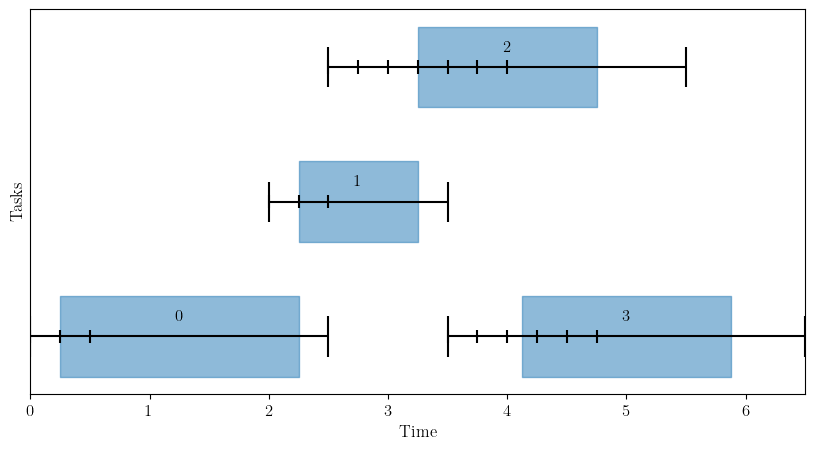

In [ ]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(10, 5))
utils.plot_windows(targets, vtws, durations, task_otws, task_targets)